# Experiment Design Project: Penguins


## Loading the Data and Splitting the Data


In [14]:
library(palmerpenguins)
data(package = 'palmerpenguins')
dim(penguins)

[1] 344   8

Data sets in package 'palmerpenguins':

penguins                Size measurements for adult foraging penguins
                        near Palmer Station, Antarctica
penguins_raw (penguins)
                        Penguin size, clutch, and blood isotope data
                        for foraging adults near Palmer Station,
                        Antarctica

In [15]:
head(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


We have 344 entries with 8 Columns in the dataset. It looks like some rows are completely full of NAs and need special treatment.


In [7]:
summary(penguins)

      species          island    bill_length_mm  bill_depth_mm  
 Adelie   :152   Biscoe   :168   Min.   :32.10   Min.   :13.10  
 Chinstrap: 68   Dream    :124   1st Qu.:39.23   1st Qu.:15.60  
 Gentoo   :124   Torgersen: 52   Median :44.45   Median :17.30  
                                 Mean   :43.92   Mean   :17.15  
                                 3rd Qu.:48.50   3rd Qu.:18.70  
                                 Max.   :59.60   Max.   :21.50  
                                 NA's   :2       NA's   :2      
 flipper_length_mm  body_mass_g       sex           year     
 Min.   :172.0     Min.   :2700   female:165   Min.   :2007  
 1st Qu.:190.0     1st Qu.:3550   male  :168   1st Qu.:2007  
 Median :197.0     Median :4050   NA's  : 11   Median :2008  
 Mean   :200.9     Mean   :4202                Mean   :2008  
 3rd Qu.:213.0     3rd Qu.:4750                3rd Qu.:2009  
 Max.   :231.0     Max.   :6300                Max.   :2009  
 NA's   :2         NA's   :2                  

From a first glance on the statistics, it looks like the numerical values are all within a reasonable range without significant outliers. The variable _species_ that will be used as a target later in the project suffers from class imblance. The data contains NA-values but very little compared to the whole dataset.


In [16]:
penguins_no_na <- na.omit(penguins)
dim(penguins_no_na)

[1] 333   8

Removing the NAs only reduced the data by 11 Rows, which is acceptable due to the fact that it is <1% of the full dataset. Since we want to do analysis on variables that had NAs (e.g. Anova based on gender) they were of no value for the use-case. The next step will be to split the data and perform further analysis on the Train-Set to gain insights into the domain.


In [45]:
set.seed(123)

n <- nrow(penguins_no_na)
idx <- sample(n) # shuffle data

train_indices <- idx[1:floor(0.7 * n)] # first 70%, train-set
val_indices <- idx[(floor(0.7 * n) + 1):floor(0.85 * n)] # 15% validation-set
test_indices <- idx[(floor(0.85 * n) + 1):n] # 15% test-set

train_set <- penguins_no_na[train_indices, ]
validation_set <- penguins_no_na[val_indices, ]
test_set <- penguins_no_na[test_indices, ]

print(dim(train_set))
print(dim(validation_set))
print(dim(test_set))

[1] 233   8
[1] 50  8
[1] 50  8


## Exploratory Data Analysis


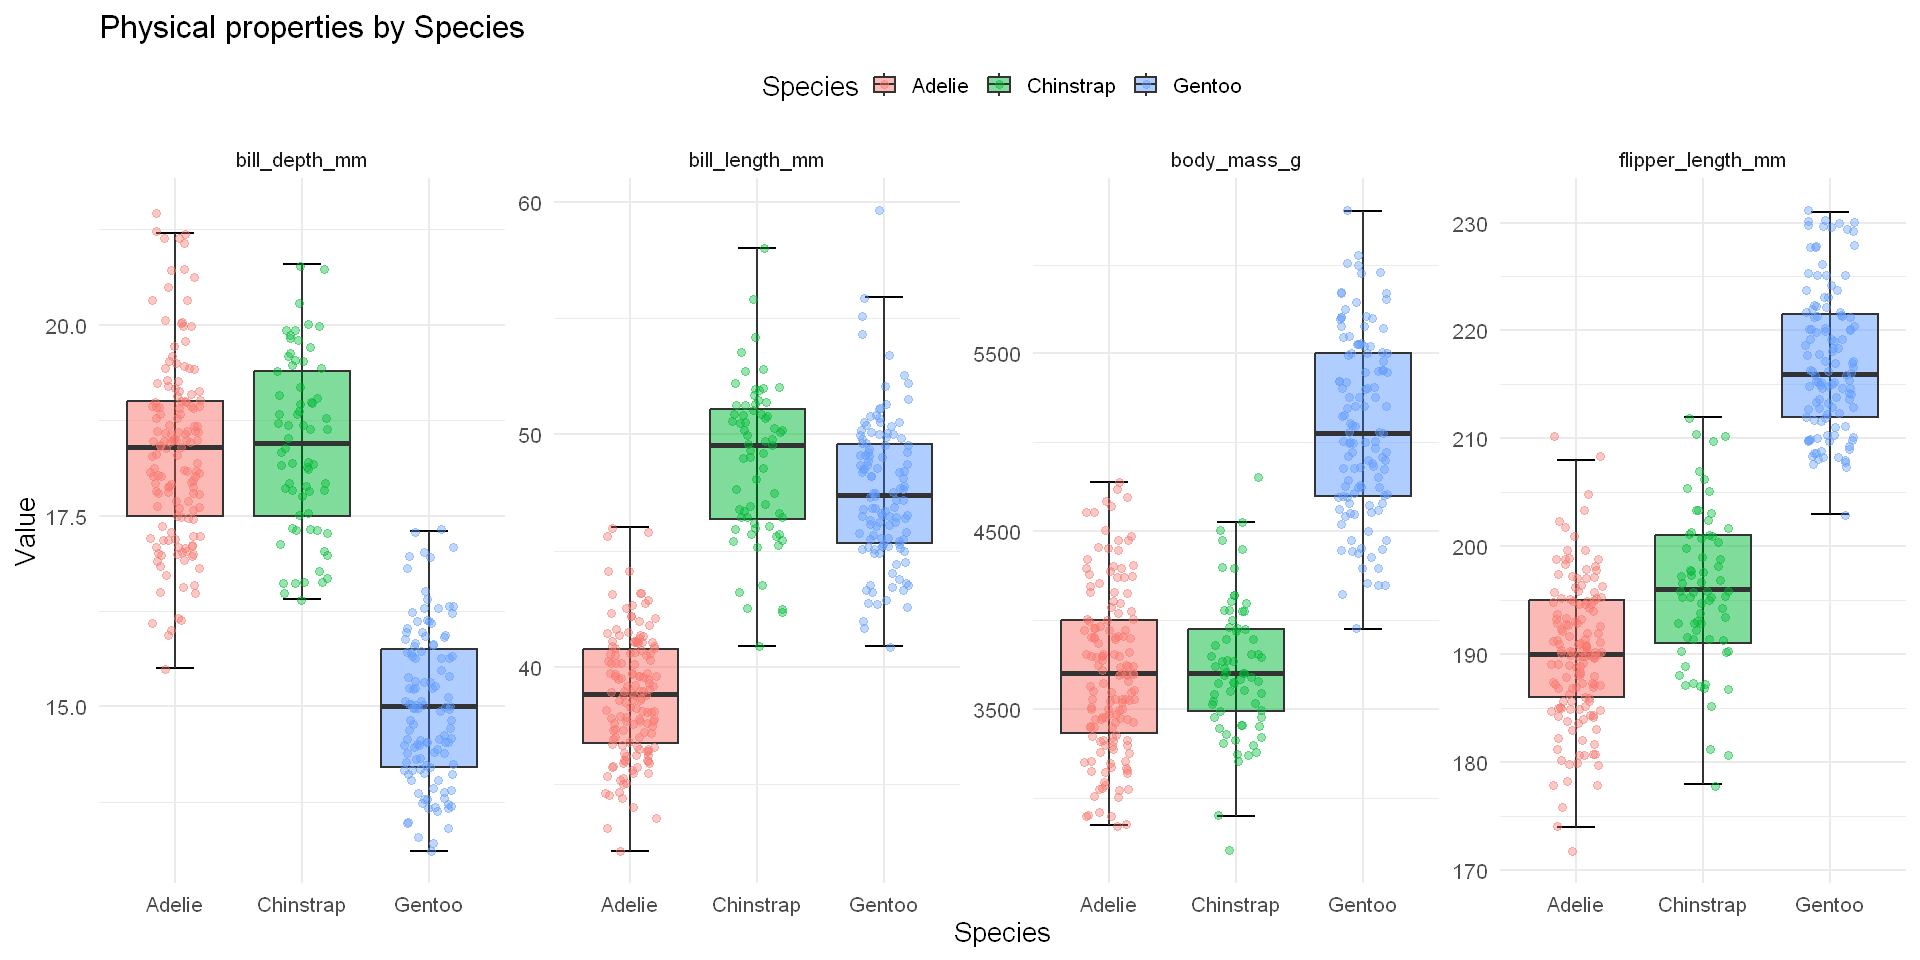

In [36]:
library(ggplot2)
library(tidyr)
library(dplyr)
options(repr.plot.width = 16, repr.plot.height = 8)

penguins_no_na |>
  pivot_longer(cols = c(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g),
               names_to = "variable", 
               values_to = "value") |>
  ggplot(aes(x = species, y = value, fill = species)) +
  stat_boxplot(geom = "errorbar", width = 0.3) + 
  geom_boxplot(outlier.shape = NA, alpha = 0.5) +
  geom_jitter(aes(color = species), width = 0.2, alpha = 0.4) + # data points, jitter moves sideways
  facet_wrap(~variable, ncol = 4, scales = "free_y") + # scale for each variable
  theme_minimal(base_size = 16) +
  labs(title = "Physical properties by Species",
       x = "Species",
       y = "Value",
       fill = "Species",
       color = "Species") +
  theme(legend.position = "top")

From the plot we can see that there are very little outliers in the data. Also the plot shows that _Gentoo_ penguins tend to be distinguishable to the others by their _bill depth_, _body mass_ and _flipper length_. On the other hand _Adelie_ and _Chinstrp_ penguins have very similar boxplots overall while the Adelie species tends to have smaller _bill lenght_ compared to the other species.


## ANOVA: Species, mass and gender


## Classification: Species


## Regression: Body Mass
